# Sprint 48 — Portage board sub-INT8 de la tête EWC

**Théorie ↔ matériel.** Le Sprint 47 (émulateur PC) a identifié *jusqu'où descendre en bits* 
à AUROC préservée, mais ne mesurait qu'une **RAM théorique bit-packée**. Ce notebook restitue 
les mesures **board réelles** (NUCLEO-F439ZI) : `.bss` packé vs non-packé (le gain devient réel), 
latence DWT du dépacking (Gap 2), et **parité board↔émulateur** (attendu 1.000).

Toutes les valeurs sont rechargées depuis `experiments/exp_S48_summary.json` (0 chiffre en dur).


In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT != ROOT.parent: ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from IPython.display import Image, display
import src.figures.catalogs  # auto-enregistrement
from src.figures.registry import get_catalog
from src.figures.style import apply_style, DEFAULT_OUT_ROOT
apply_style('slide')
print('setup OK — racine', ROOT)


setup OK — racine /home/leonard/Documents/ENAC/cl-embedded


## 1. Génération des figures board

Le catalogue `quant_depth_board` skippe gracieusement si l'agrégat est absent.


In [2]:
paths = get_catalog('quant_depth_board')(DEFAULT_OUT_ROOT)
print(f'{len(paths)} figure(s) générée(s)')
for p in paths: print(' -', p)


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/board_auroc_vs_bits.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/bss_packed_vs_unpacked.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/latency_vs_bits.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/parity_board_pc.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/heatmap_board_bits_dataset.png
5 figure(s) générée(s)
 - /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/board_auroc_vs_bits.png
 - /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/bss_packed_vs_unpacked.png
 - /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/latency_vs_bits.png
 - /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/parity_board_pc.png
 - /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quant_depth_board/heatmap_board_bits_dataset.png


## 2. Galerie


bss_packed_vs_unpacked


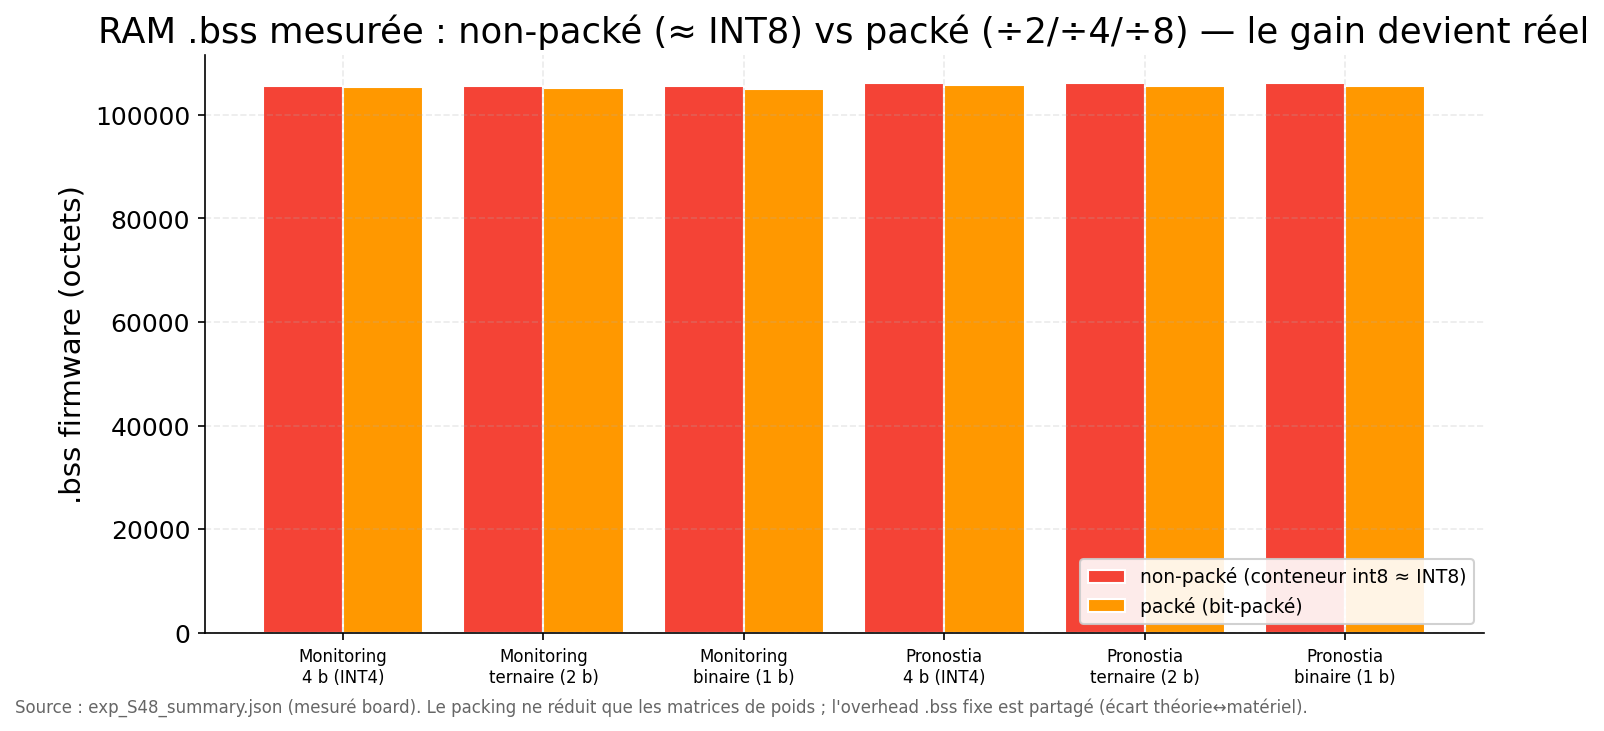

board_auroc_vs_bits


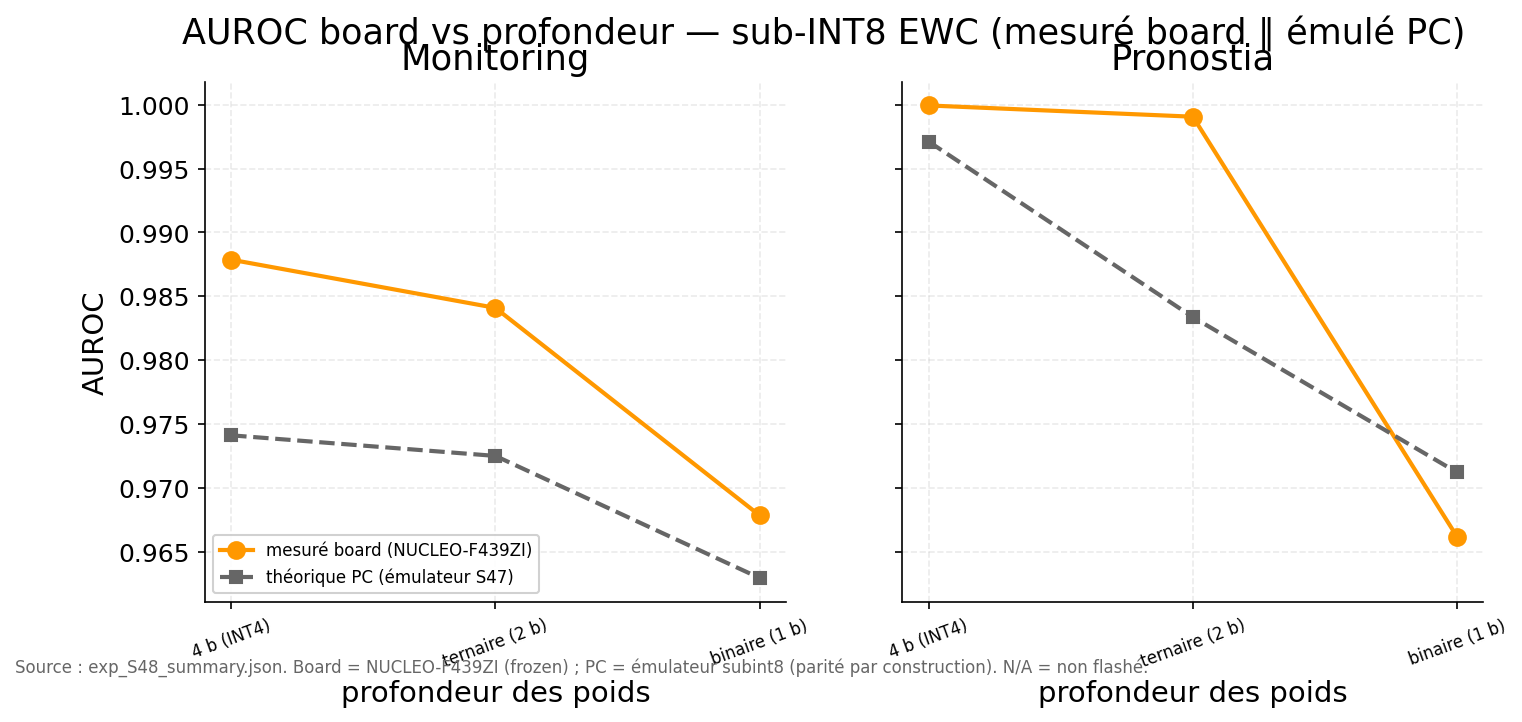

latency_vs_bits


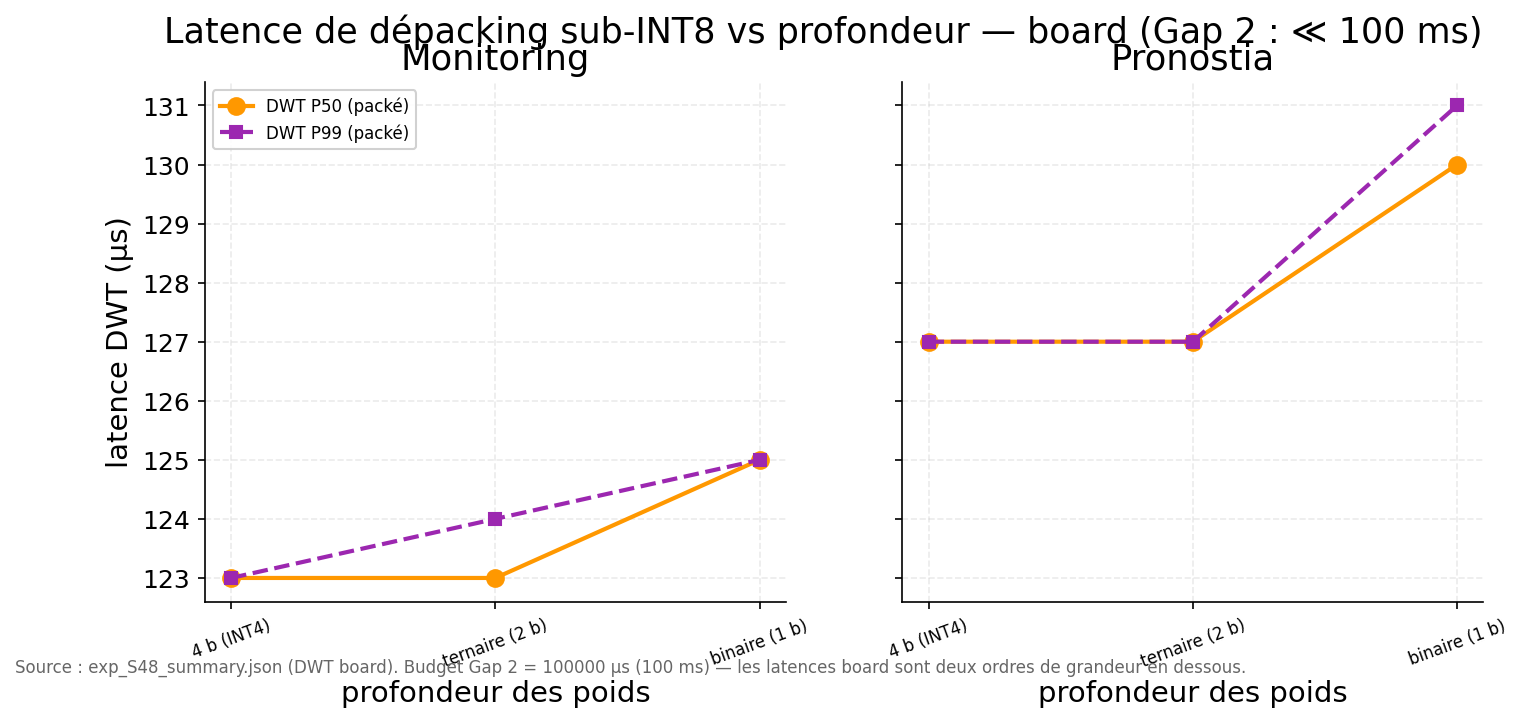

parity_board_pc


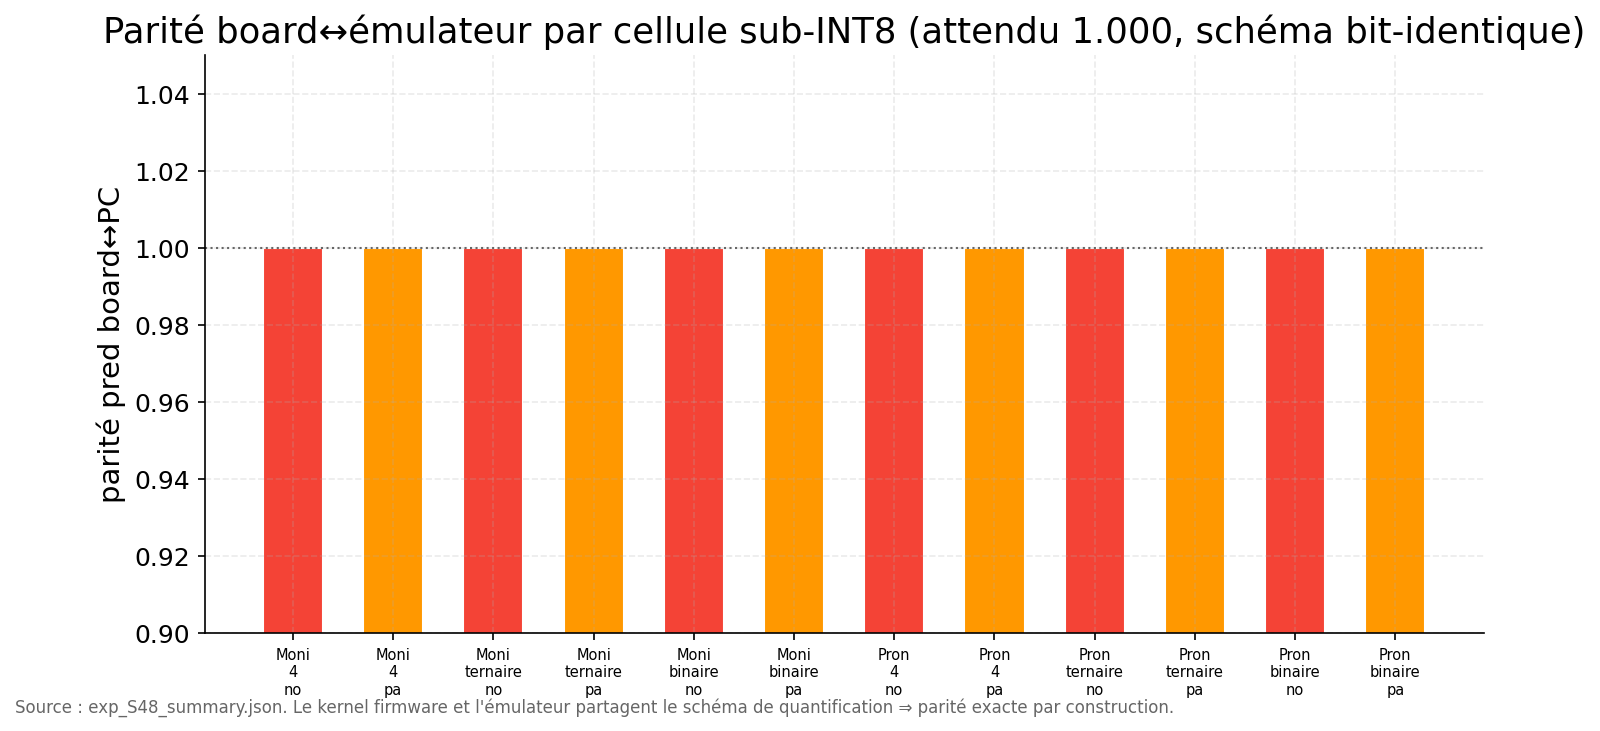

heatmap_board_bits_dataset


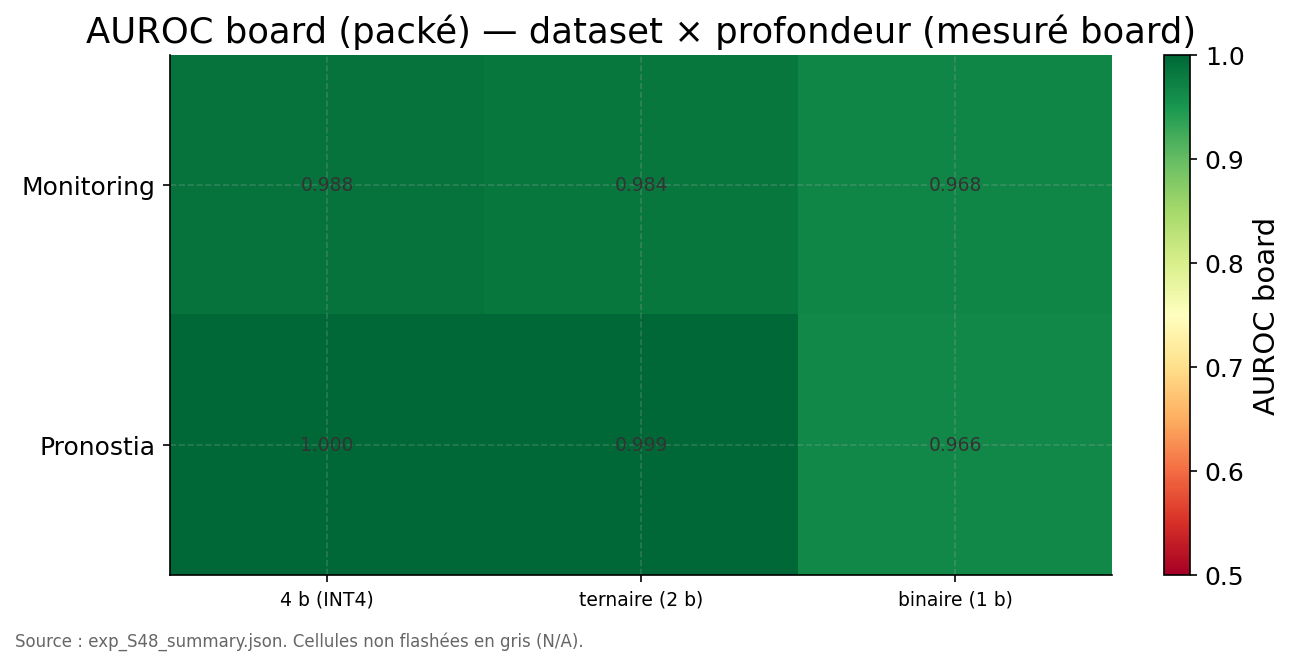

In [3]:
for name in ['bss_packed_vs_unpacked','board_auroc_vs_bits','latency_vs_bits','parity_board_pc','heatmap_board_bits_dataset']:
    f = DEFAULT_OUT_ROOT/'quant_depth_board'/f'{name}.png'
    if f.exists():
        print(name); display(Image(filename=str(f)))
    else:
        print('(absent)', name)


## 3. Synthèse théorie ↔ matériel

Pour chaque (dataset, profondeur) : `.bss` mesuré non-packé (≈ INT8) vs packé, octets économisés 
par le bit-packing, ratio RAM **théorique** (S47), latence DWT packée et parité board↔PC.


In [4]:
summary_path = ROOT/'experiments'/'exp_S48_summary.json'
if not summary_path.exists():
    print('exp_S48_summary.json absent — lancer aggregate_sprint48.py')
else:
    S = json.loads(summary_path.read_text())
    rows = []
    for ds, per_bits in S['results_by_condition'].items():
        for bits, per_gran in per_bits.items():
            c = per_gran['per_channel']
            npk = (c['board'].get('nonpacked') or {})
            pk = (c['board'].get('packed') or {})
            pc = c.get('pc') or {}
            rows.append({
                'dataset': ds, 'bits': bits,
                'bss_nonpacked': npk.get('bss_bytes'), 'bss_packed': pk.get('bss_bytes'),
                'saved_B': c['board'].get('bss_saved_by_packing'),
                'ram_ratio_theo_vsFP32': pc.get('ram_ratio_theoretical_vs_fp32'),
                'lat_p50_us': pk.get('latency_dwt_p50_us'),
                'parity_pk': pk.get('parity_pred'),
                'auroc_board_pk': pk.get('auroc_board'),
                'auroc_pc': pc.get('auroc_quant'),
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for r in rows: print(r)


,dataset,bits,bss_nonpacked,bss_packed,saved_B,ram_ratio_theo_vsFP32,lat_p50_us,parity_pk,auroc_board_pk,auroc_pc
0,monitoring,4,105640,105304,336,8.0000,123.0,1.0,0.987871,0.974112
1,monitoring,2,105640,105136,504,20.2532,123.0,1.0,0.984095,0.972498
2,monitoring,1,105640,105068,572,32.0000,125.0,1.0,0.967839,0.962937
3,pronostia,4,106152,105816,336,8.0000,127.0,1.0,0.999951,0.997122
4,pronostia,2,106152,105648,504,20.2532,127.0,1.0,0.999070,0.983371
5,pronostia,1,106152,105548,604,32.0000,130.0,1.0,0.966164,0.971203


## 4. Lecture

- **`.bss` packé < non-packé** : le bit-packing matérialise le ÷2/÷4/÷8 sur les matrices de poids 
  (le reste du `.bss` est un overhead fixe partagé → l'écart théorie↔matériel est explicite).
- **Latence DWT ≪ 100 ms** : le dépacking sub-INT8 reste deux ordres de grandeur sous le budget Gap 2.
- **Parité board↔émulateur = 1.000** : le kernel firmware et l'émulateur subint8 partagent le schéma 
  de quantification ⇒ parité exacte par construction (précédent S34/S45).

_Toutes les valeurs proviennent des JSON mesurés ; aucune n'est écrite en dur._
